<a href="https://colab.research.google.com/github/dherreraal/object_oriented_programming/blob/main/Clase_07/07_POO_Estructuras_Complementarias_Switch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Estructuras de Selección Complementarias
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez  
#### **Curso:** Programación Orientada a Objetos (POO)
---


## Índice de Contenido
1. Introducción a las estructuras complementarias
2. La estructura `switch` (Selección múltiple tradicional)
    - 2.1 Sintaxis y funcionamiento
    - 2.2 Reglas y restricciones del `switch`
    - 2.3 Ejemplo: Evaluación de calificaciones
3. Diferencias y casos de uso: `if-else if` vs `switch`
4. El problema del "Else Colgante" (Dangling Else)
    - 4.1 Concepto y cómo evitarlo
5. El `switch` moderno como Expresión (Novedad Java 14+)
    - 5.1 Sintaxis con flecha (`->`)
6. Uso de Enumeraciones (`enum`) junto al `switch`
7. Ejercicios Prácticos
8. Bibliografía
---


## 1. Introducción a las estructuras complementarias

En la guía anterior exploramos las estructuras de selección fundamentales como el `if`, `if-else` y las estructuras anidadas `if-else if`. Estas estructuras son muy versátiles, pero en ocasiones, cuando tenemos múltiples caminos posibles basados en el valor exacto de una única variable, el código puede volverse repetitivo y difícil de leer.

En esta guía, introduciremos la estructura `switch`, que actúa como un evaluador de casos múltiples (multi-way), simplificando la toma de decisiones. Además, discutiremos un error lógico común en la programación conocido como el "Else Colgante" (Dangling Else).

## 2. La estructura `switch` (Selección múltiple)

A medida que el número de declaraciones `if` anidadas aumenta, el código resultante puede ser difícil de leer y mantener. Para ayudar en estas situaciones, Java cuenta con la estructura `switch`.

Un `switch` evalúa el contenido de una variable simple o el resultado de una expresión, y transfiere el flujo de control a un caso (`case`) particular que coincida con ese valor, ejecutando el código correspondiente.

<p align="center">
  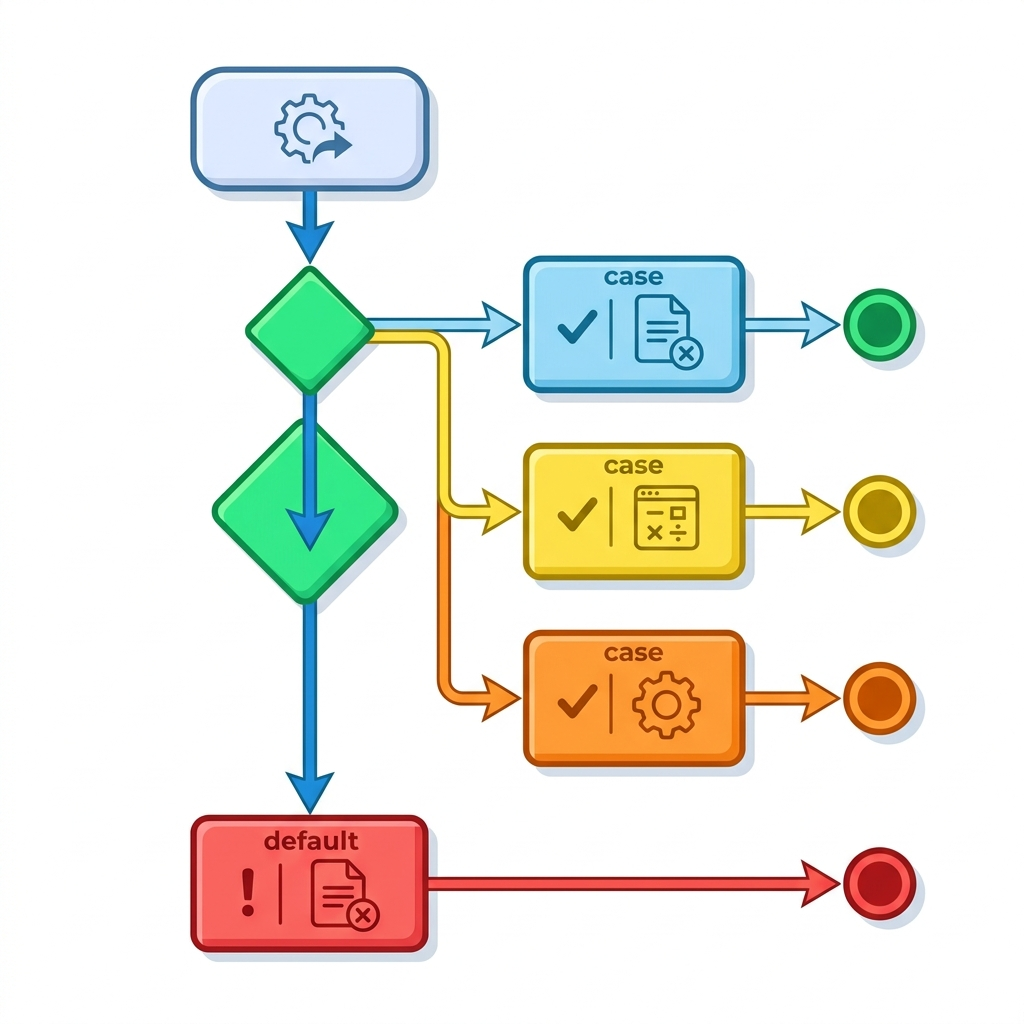
</p><p align="center"><i>Figura 1: Diagrama de flujo de la estructura Switch tradicional.</i></p>

### 2.1 Sintaxis y funcionamiento

La estructura general de un `switch` es la siguiente:

```java
switch (variable_a_evaluar) {
    case valor1:
        // Código a ejecutar si variable == valor1
        break; // Sale del switch
    case valor2:
        // Código a ejecutar si variable == valor2
        break;
    default:
        // Código a ejecutar si ningún caso anterior coincide
        // No es obligatorio, pero se recomienda como medida de precaución.
}
```

**Nota sobre `break` y `default`:**
- **`break`**: Si no incluimos un `break`, el flujo de ejecución "caerá" (fall-through) hacia el siguiente caso, ejecutando su código aunque el valor no coincida. Esto raramente es deseado y se considera mala práctica si no se documenta.
- **`default`**: Aunque no es estrictamente necesario, es una buena práctica incluirlo para manejar valores inesperados y prevenir errores lógicos.


In [1]:
%%writefile EjemploSwitchBasico.java
import java.util.Scanner;

public class EjemploSwitchBasico {
    public static void main(String[] args) {
        Scanner scanner = new Scanner(System.in);
        System.out.print("Ingrese un número del 1 al 3: ");
        int opcion = scanner.nextInt();

        switch (opcion) {
            case 1:
                System.out.println("Ha seleccionado la Opción 1.");
                break;
            case 2:
                System.out.println("Ha seleccionado la Opción 2.");
                break;
            case 3:
                System.out.println("Ha seleccionado la Opción 3.");
                break;
            default:
                System.out.println("Opción no válida. Por favor, intente de nuevo.");
                break;
        }
        System.out.println("Fin del programa.");
    }
}


Writing EjemploSwitchBasico.java


In [2]:
!javac EjemploSwitchBasico.java
!java EjemploSwitchBasico


[0.028s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.028s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Ingrese un número del 1 al 3: 2
Ha seleccionado la Opción 2.
Fin del programa.



### 2.2 Reglas y restricciones del `switch`

Es importante conocer algunas de las limitaciones y reglas al usar un `switch` en Java:
1. **Tipos de datos permitidos:** Tradicionalmente, `switch` solo soportaba `byte`, `short`, `char` e `int` (y sus correspondientes clases Wrapper). A partir de Java 7, también es posible evaluar cadenas de texto (`String`). **No se pueden usar `float` o `double`** dentro del condicional de un `switch`.
2. **Evaluación de igualdad exacta:** En los `case` no se pueden colocar rangos (por ejemplo: `case > 10:`). Cada `case` debe evaluar un valor constante y exacto.

### 2.3 Ejemplo: Evaluación de calificaciones

Imagina que necesitamos imprimir un mensaje basado en la nota de un examen (de 0 a 100). Usar un `switch` para los 100 posibles valores sería inviable. Sin embargo, si los rangos son múltiplos de 10 (90-100 Excelente, 80-89 Bueno, etc.), podemos usar un truco: **dividir la nota entre 10**.

Como la división entre enteros en Java descarta los decimales, `95 / 10 = 9`, `82 / 10 = 8`. ¡Esto nos permite usar el `switch`!


In [3]:
%%writefile SwitchRangoNotas.java
import java.util.Scanner;

public class SwitchRangoNotas {
    public static void main(String[] args) {
        Scanner sc = new Scanner(System.in);
        System.out.print("Ingrese el puntaje del examen (0 - 100): ");
        int score = sc.nextInt();

        // Primero validamos el rango para evitar entradas fuera de lo común
        if (score < 0 || score > 100) {
            System.out.println("El puntaje ingresado es inválido.");
        } else {
            // Dividimos por 10 para agrupar por decenas
            switch (score / 10) {
                case 10:
                case 9:
                    System.out.println("Calificación: ¡Muy Bien! (A)");
                    break;
                case 8:
                    System.out.println("Calificación: Bien (B)");
                    break;
                case 7:
                    System.out.println("Calificación: Regular (C)");
                    break;
                case 6:
                    System.out.println("Calificación: Suficiente (D)");
                    break;
                default:
                    // Esto atrapará los valores de 0 a 59 (casos 5, 4, 3, 2, 1, 0)
                    System.out.println("Calificación: Insuficiente (F)");
                    break; // break final opcional, pero buena práctica
            }
        }
    }
}


Writing SwitchRangoNotas.java


In [4]:
!javac SwitchRangoNotas.java
!java SwitchRangoNotas


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Ingrese el puntaje del examen (0 - 100): 56
Calificación: Insuficiente (F)



## 3. Diferencias y casos de uso: `if-else if` vs `switch`

Dado que `switch` y `if-else if` solucionan problemas similares, surge la pregunta: ¿Cuándo usar cada uno?

*   **Usar `if-else if` cuando:**
    *   Existan condiciones complejas y múltiples (ej: `if (a > b && c == 0)`).
    *   Tengamos que evaluar rangos de valores arbitrarios o desiguales (ej: valores entre 15 y 43).
    *   Tengamos variables con punto flotante (`double`, `float`).
    *   Solo haya 2 o 3 alternativas. En ese caso un `switch` es demasiado extenso (overkill).

*   **Usar `switch` cuando:**
    *   Existan 5 o más alternativas posibles basadas en el **mismo** valor o variable.
    *   Se realicen evaluaciones de variables discretas como `int`, `char` o `String` comparadas con valores exactos.
    *   Queramos mejorar la legibilidad y claridad de una gran cantidad de selecciones.

---

## 4. El problema del "Else Colgante" (Dangling Else)

Un error lógico muy común en la anidación de estructuras `if-then-if` sin utilizar llaves `{}` se denomina el **problema del else colgante** (*Dangling Else*).

En Java, un `else` siempre se asocia (se empareja) con el **`if` más cercano** que lo preceda dentro del mismo bloque y que no tenga ya un `else` asignado. Si la indentación de nuestro código dice una cosa, pero la sintaxis de Java dicta otra, tendremos un problema lógico.

### 4.1 Concepto y cómo evitarlo

Observa el siguiente código mal estructurado:

```java
int x = 10;
int y = 5;

// Código engañoso debido a la mala indentación
if (x > 5)
    if (y > 5)
        System.out.println("X e Y son mayores a 5");
else
    System.out.println("X NO es mayor a 5");
```

A primera vista, la indentación sugiere que el `else` pertenece al **primer** `if` (`if (x > 5)`). Si `x = 10` e `y = 5`, el programador esperaría que no pasara nada. Sin embargo, Java lo lee así:

```java
if (x > 5) {
    if (y > 5) {
        System.out.println("X e Y son mayores a 5");
    } else {
        // El else se asoció al if más cercano (el if anidado)
        System.out.println("X NO es mayor a 5");
    }
}
```
Por lo tanto, la salida será `"X NO es mayor a 5"`, lo cual es semánticamente **incorrecto** según la lógica del programa (ya que X ¡sí es 10!).

**Solución:** La única y mejor manera de evitar el problema del *Dangling Else* es **utilizar siempre llaves `{}`** para definir claramente los bloques `if` y `else`, incluso si estos contienen una sola línea de código.


In [5]:
%%writefile DanglingElse.java
public class DanglingElse {
    public static void main(String[] args) {
        int x = 10;
        int y = 5;

        System.out.println("--- Demostración del Else Colgante ---");
        // ESTO CAUSA UN ERROR LÓGICO
        if (x > 5)
            if (y > 5)
                System.out.println("X e Y son mayores a 5");
        else
            System.out.println("ESTA LÍNEA ES UN ERROR LÓGICO: X supuestamente NO es mayor a 5");

        System.out.println("\n--- Solución usando Llaves ---");
        // LA FORMA CORRECTA Y SEGURA
        if (x > 5) {
            if (y > 5) {
                System.out.println("X e Y son mayores a 5");
            }
        } else {
            System.out.println("X NO es mayor a 5");
        }
        System.out.println("Ejecución terminada correctamente.");
    }
}


Writing DanglingElse.java


In [6]:
!javac DanglingElse.java
!java DanglingElse


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
--- Demostración del Else Colgante ---
ESTA LÍNEA ES UN ERROR LÓGICO: X supuestamente NO es mayor a 5

--- Solución usando Llaves ---
Ejecución terminada correctamente.


## 5. El `switch` moderno como Expresión (Novedad Java 14+)

El `switch` tradicional que vimos arriba funciona muy bien, pero tiene algunos problemas de diseño histórico:
- Si olvidamos un `break`, ocurre el temido *fall-through* y se ejecutan bloques de código no deseados.
- Es muy verboso (requiere muchas líneas de código para algo sencillo).
- No puede retornar un valor directamente para asignarlo a una variable.

A partir de Java 14, se introdujo una mejora espectacular: el **`switch` expression** (el `switch` como expresión que retorna un valor).

<p align="center">
  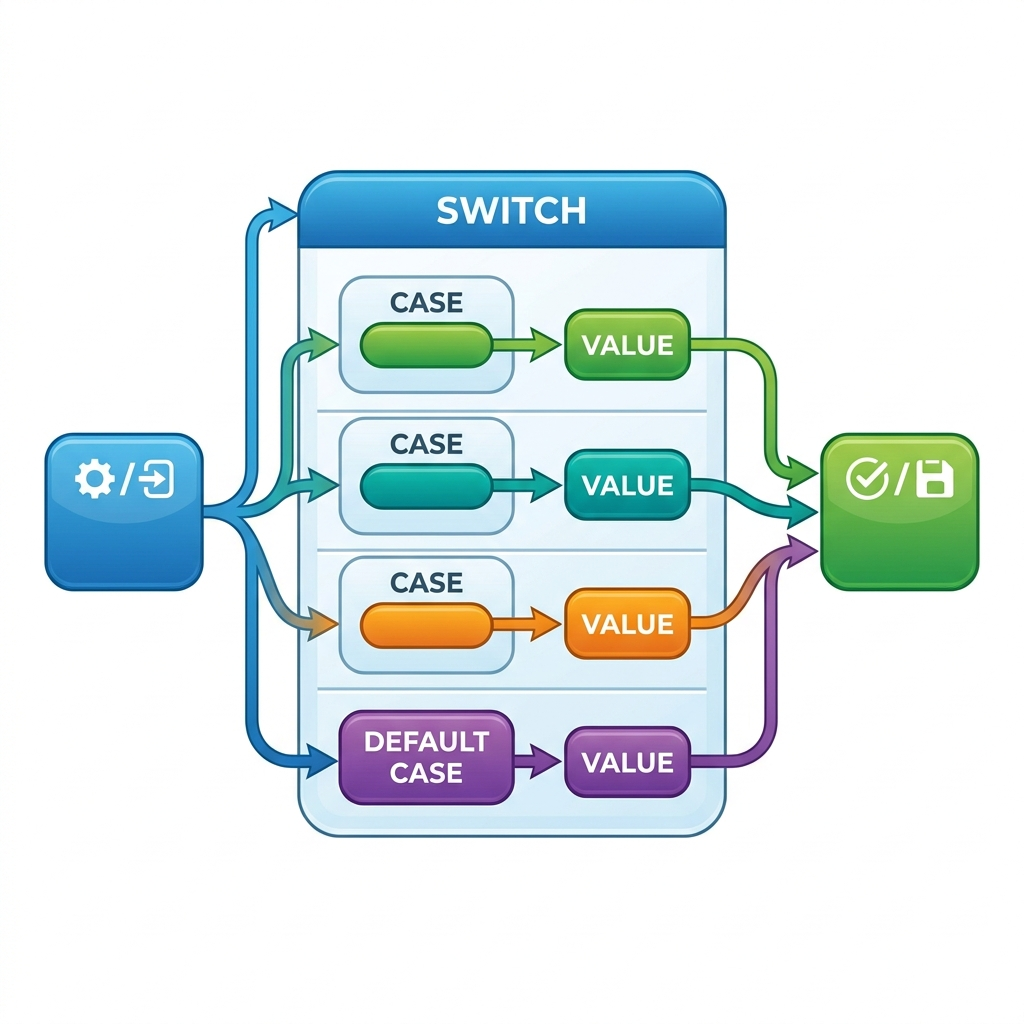
</p><p align="center"><i>Figura 2: Estructura del Switch moderno (Expression) que retorna un valor sin necesidad de usar break.</i></p>

### 5.1 Sintaxis con flecha (`->`)

Con la nueva sintaxis, usamos `->` (flecha) en lugar de `:` (dos puntos). **Esto elimina por completo la necesidad de usar `break`**, ya que solo se ejecutará la línea apuntada por la flecha.
Además, permite asignar el resultado directamente a una variable.


In [7]:
%%writefile SwitchModerno.java
public class SwitchModerno {
    public static void main(String[] args) {
        int dia = 3;

        // Asignación directa y sin breaks (Java 14+)
        String tipoDia = switch (dia) {
            case 1, 2, 3, 4, 5 -> "Día laborable"; // Múltiples casos en una sola línea
            case 6, 7 -> "Fin de semana";
            default -> "Día inválido";
        };

        System.out.println("El día " + dia + " es un: " + tipoDia);
    }
}


Writing SwitchModerno.java


In [8]:
!javac SwitchModerno.java
!java SwitchModerno


[0.002s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.002s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
El día 3 es un: Día laborable


## 6. Uso de Enumeraciones (`enum`) junto al `switch`

Una de las mejores prácticas en la Programación Orientada a Objetos para hacer que nuestros `switch` sean **fuertemente tipados** (Type-safe) es utilizar Enumeraciones (`enum`).

Un `enum` es un tipo de dato especial en Java que nos permite definir un conjunto de constantes predefinidas. En lugar de pedirle al usuario que ingrese "1" para Lunes, y "2" para Martes (donde podría ingresar un "8" y romper la lógica), usamos un `enum` para representar estrictamente los días válidos.


In [9]:
%%writefile EnumSwitch.java
// 1. Declaramos la enumeración fuera de la clase principal (o dentro)
enum DiaSemana {
    LUNES, MARTES, MIERCOLES, JUEVES, VIERNES, SABADO, DOMINGO
}

public class EnumSwitch {
    public static void main(String[] args) {
        // En lugar de int o String, nuestra variable es de tipo DiaSemana
        DiaSemana diaDeHoy = DiaSemana.VIERNES;

        // Evaluamos el enum en un switch moderno
        switch (diaDeHoy) {
            case LUNES, MARTES, MIERCOLES, JUEVES -> System.out.println("Aún falta para el fin de semana.");
            case VIERNES -> System.out.println("¡Es viernes y el compilador lo sabe!");
            case SABADO, DOMINGO -> System.out.println("¡A descansar!");
        }
        // Nota: Si el switch moderno no retorna un valor (solo ejecuta código),
        // no es obligatorio tener el default si hemos cubierto todos los casos del enum.
    }
}


Writing EnumSwitch.java


In [10]:
!javac EnumSwitch.java
!java EnumSwitch


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
¡Es viernes y el compilador lo sabe!


## 7. Ejercicios Prácticos

### Ejercicio 1: Calculadora Básica con `switch`
Escribe un programa que pida al usuario dos números enteros y un operador aritmético (`+`, `-`, `*`, `/` en formato de `String` o `char`). Usa una estructura `switch` para evaluar el operador y mostrar el resultado de la operación correspondiente. Incluye un mensaje de error si se divide por cero y una opción `default` por si ingresa un operador inválido.


In [11]:
%%writefile Calculadora.java
import java.util.Scanner;

public class Calculadora {
    public static void main(String[] args) {
        Scanner scanner = new Scanner(System.in);
        System.out.println("--- Calculadora Básica ---");

        // 1. Pide al usuario el primer número
        System.out.print("Ingrese el primer número: ");
        int num1 = scanner.nextInt();

        // 2. Pide el operador
        System.out.print("Ingrese el operador (+, -, *, /): ");
        char operador = scanner.next().charAt(0);

        // 3. Pide el segundo número
        System.out.print("Ingrese el segundo número: ");
        int num2 = scanner.nextInt();

        int resultado = 0;
        boolean error = false;

        // 4. Utiliza el switch para evaluar la operación
        // TU CÓDIGO AQUÍ:
        /* switch(operador) {
             case '+':
                 resultado = num1 + num2;
                 break;
             // ... completar los demás
        } */

        if (!error) {
            System.out.println("El resultado es: " + resultado);
        }
    }
}


Writing Calculadora.java


In [12]:
!javac Calculadora.java
!java Calculadora


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
--- Calculadora Básica ---
Ingrese el primer número: 

### Ejercicio 2 y 3: Identificador de Meses y Estaciones
Pide al usuario que ingrese un número del 1 al 12 y utiliza un `switch` para imprimir el nombre del mes correspondiente.
Luego, utiliza un segundo `switch` para imprimir la estación agrupando los casos. Por ejemplo, los meses 12, 1 y 2 que muestren el mensaje "Es Invierno". Aprovecha la propiedad de "fall-through" intencionalmente (es decir, poner varios `case` seguidos sin `break`) para resolverlo con menos líneas de código.


In [13]:
%%writefile MesesEstaciones.java
import java.util.Scanner;

public class MesesEstaciones {
    public static void main(String[] args) {
        Scanner scanner = new Scanner(System.in);
        System.out.print("Ingrese el número del mes (1-12): ");
        int mes = scanner.nextInt();

        System.out.print("El mes es: ");
        // 1. Switch para el nombre del mes
        // TU CÓDIGO AQUÍ


        System.out.print("\nLa estación es: ");
        // 2. Switch para la estación agrupando los casos sin break (fall-through)
        // Ejemplo: Invierno (12, 1, 2), Primavera (3, 4, 5), Verano (6, 7, 8), Otoño (9, 10, 11)
        // TU CÓDIGO AQUÍ

    }
}


Writing MesesEstaciones.java


In [14]:
!javac MesesEstaciones.java
!java MesesEstaciones


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Ingrese el número del mes (1-12): 

## 8. Bibliografía

*   Streib, J. T., & Soma, T. (2014). *Guide to Java: A Concise Introduction to Programming*. Springer-Verlag London. (Capítulo 3: Selection Structures).
